## Импорты

In [2]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.datasets import make_classification
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

# Формула Naive Bayes

## Общая формула

$$
P(C_k \mid x_1, \dots, x_n) = \frac{P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k)}{P(x_1, \dots, x_n)}
$$
**для каждого $P(x_i \mid C_k)$ отличается признак $x_i$, а не объект.**
## Решающее правило (предсказание)

$$
\boxed{\hat{y} = \arg\max_{k} \left[ P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k) \right]}
$$

## Гауссовская плотность (для непрерывных признаков)

$$
\boxed{P(x_i \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_{k,i}^2}} \exp\left(-\frac{(x_i - \mu_{k,i})^2}{2\sigma_{k,i}^2}\right)}
$$

## Полная формула для гауссовского Naive Bayes

$$
P(C_k \mid \mathbf{x}) \propto P(C_k) \prod_{i=1}^{d} \frac{1}{\sqrt{2\pi\sigma_{k,i}^2}} \exp\left(-\frac{(x_i - \mu_{k,i})^2}{2\sigma_{k,i}^2}\right)
$$

## Логарифмическая форма (численно устойчивая)

$$
\log P(C_k \mid \mathbf{x}) \propto \log P(C_k) + \sum_{i=1}^{d} \left[ -\log\left(\sqrt{2\pi\sigma_{k,i}^2}\right) - \frac{(x_i - \mu_{k,i})^2}{2\sigma_{k,i}^2} \right]
$$


## Гауссовский наивный байес с Хабра

In [2]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        classes, cls_counts = np.unique(y, return_counts=True)
        n_classes = len(classes)
        self.priors = cls_counts / len(y)

        # calculate the mean and standard deviations of features by classes
        self.X_cls_mean = np.array([np.mean(X[y == c], axis=0) for c in range(n_classes)])
        self.X_stds = np.array([np.std(X[y == c], axis=0) for c in range(n_classes)])

    # calculate the probability density of the feature according to the Gaussian distribution
    def pdf(self, x, mean, std):
        return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(-0.5 * ((x - mean) / std) ** 2)

    def predict(self, X):
        pdfs = np.array([self.pdf(x, self.X_cls_mean, self.X_stds) for x in X])
        self.posteriors = self.priors * np.prod(pdfs, axis=2)   # shorten Bayes formula

        return np.argmax(self.posteriors, axis=1)

## Мой Гауссовский (параметрический) наивный байес

In [9]:
class ParamNaiveBayes():
    def fit(self, X, y):
        classes, n_classes = np.unique(y, return_counts = True)
        self.sigmas = {}
        self.mus = {}
        self.priors = {classes[i] : n_classes[i] / len(y) for i in range(len(classes))}
        for cl in classes:
            batch_X = X[y == cl]
            mu = np.mean(batch_X, axis = 0)
            #print(mu)
            #print(np.mean(batch_X))       # значения берутся отдельно для признаков и затем признаковые значения относят к классу
            sigma = np.std(batch_X, axis = 0)
            self.mus[cl] = mu
            self.sigmas[cl] = sigma
    
    def _density(self, X, stds, means):

        # Почему дополнительный цикл или ось - дело в том, что мы обрабатываем каждое значение из каждого столбца с признаками при помощи std, mean
        
        """results = []
        for x in X: 
            res = -np.log(np.sqrt(2 * np.pi) * stds) - 0.5 * (((x - means) / stds) ** 2)
            results.append(np.sum(res, axis=1))
        return np.array(results)  """
        
        X_expanded = X[:, np.newaxis, :]  # (n_samples, 1, n_features)
        means_expanded = means[np.newaxis, :, :]  # (1, n_classes, n_features)
        stds_expanded = stds[np.newaxis, :, :]    # (1, n_classes, n_features)
    
        res = -np.log(np.sqrt(2 * np.pi) * stds_expanded) -0.5 * (((X_expanded - means_expanded) / stds_expanded) ** 2)
        
        return np.sum(res, axis=2)  # каждый x включает список из n_classes списков (то есть 3 оси)


    def predict(self, X):

        sigma_values = np.array(list(self.sigmas.values()))
        mu_values = np.array(list(self.mus.values()))
        prior_values = np.array(list(self.priors.values()))
        
        log_densities = self._density(X, sigma_values, mu_values)
        log_priors = np.log(prior_values)
        self.posts = log_priors + log_densities # теперь каждый x имеет список из значений апостериорной вероятности для каждого класса (матрица)
        keys = list(self.sigmas.keys())
        result = np.argmax(self.posts, axis=1)  # оси тут можно интерпертировать как степень вложенности списков от 0 до 2
        predictions = np.take(keys, result)

        return predictions

## Мой непараметрический наивный байес

In [4]:
class NonParamNaiveBayes():
    def __init__(self, h, kernel = "uniform"):
        if kernel == "uniform":
            self.kernel = lambda u: 0.5 * np.where(np.abs(u) < 1, 1, 0)
        elif kernel == 'gaussian':
            self.kernel = lambda u: np.exp(-u**2 / 2) / np.sqrt(2 * np.pi)
        self.h = h

    def fit(self, X, y):

        unique, counts = np.unique(y, return_counts=True)
        self.y_classes = dict(zip(unique, counts))
        #y_classes = {cl : num for cl, num in zip(unique, counts)}
        self.X_batch = [X[y == cl] for cl in self.y_classes.keys()]

    def kernel_func(self,x_test,X_train):
        return (x_test - X_train) / self.h   # один вектор признаков (d,) минус матрица объектов (n, d)
        
    def estimate(self, x_test, X_train):
        m = len(X_train)
        K_func = self.kernel_func(x_test,X_train)
        return 1/(self.h*m) * np.sum(self.kernel(K_func))
        
    def predict(self, X):

        predictions = []
        for x in X:
            densities = [self.estimate(x, X_class) for X_class in self.X_batch]
            best_idx = np.argmax(densities)
            predictions.append(list(self.y_classes.keys())[best_idx])

        return np.array(predictions)

## Датасеты

In [5]:
X1, y1 = load_iris(return_X_y=True, as_frame=True)
X1_train, X1_test, y1_train, y1_test = train_test_split(X1.values, y1.values, random_state=2)

X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_classes=4,
    n_clusters_per_class=1,
    random_state=40
)

# Разделяем (80% train, 20% test, сохраняем пропорции классов)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% на тест
    random_state=42,        # для воспроизводимости
    stratify=y              # сохраняет пропорцию классов
)

## Тесты + эталон sklearn

In [10]:
start = time.time()
npunb = NonParamNaiveBayes(h=1.5, kernel = "uniform")
npunb.fit(X1_train, y1_train)
y3_pred = npunb.predict(X1_test)
my_time1 = time.time() - start
print(f'My Non-Param NaiveBayes, kernel=uniform: {accuracy_score(y1_test, y3_pred)*100}%, Time: {my_time1:.6f}s')

start = time.time()
npgnb = NonParamNaiveBayes(h=0.75, kernel = "gaussian")
npgnb.fit(X1_train, y1_train)
y5_pred = npgnb.predict(X1_test)
my_time3 = time.time() - start
print(f'My Non-Param NaiveBayes, kernel=gaus: {accuracy_score(y1_test, y5_pred)*100}%, Time: {my_time3:.6f}s')

start = time.time()
nb = ParamNaiveBayes()
nb.fit(X1_train, y1_train)
y1_pred = nb.predict(X1_test)
my_time2 = time.time() - start
print(f'My NaiveBayes + log: {accuracy_score(y1_test, y1_pred)*100}%, Time: {my_time2:.6f}s')

start = time.time()
gnb = GaussianNaiveBayes()
gnb.fit(X1_train, y1_train)
y2_pred = gnb.predict(X1_test)
habr_time = time.time() - start
print(f'Habr NaiveBayes: {accuracy_score(y1_test, y2_pred)*100}%, Time: {habr_time:.6f}s')

start = time.time()
sk_nb = GaussianNB()
sk_nb.fit(X1_train, y1_train)
y4_pred = sk_nb.predict(X1_test)
sk_time = time.time() - start
print(f'Sklearn NaiveBayes: {accuracy_score(y1_test, y4_pred)*100}%, Time: {sk_time:.6f}s')

print(f'N_Diff: {np.sum(y2_pred != y1_pred)}')
print(f'N_Diff: {np.sum(y5_pred != y1_pred)}')
print(f'N_Diff: {np.sum(y3_pred != y1_pred)}')
print(f'N_Diff: {np.sum(y4_pred != y1_pred)}')

My Non-Param NaiveBayes, kernel=uniform: 95.0%, Time: 0.002058s
My Non-Param NaiveBayes, kernel=gaus: 90.0%, Time: 0.002855s
[-1.26481017 -1.28106149 -1.52454648  0.23915473 -0.31474825]
-0.8292023320857314
[-1.00358165  0.99047193 -0.65019177  0.65138118 -0.08892284]
-0.020168630305229026
[ 1.25726262 -0.94873626  0.89597454 -0.74884757 -0.14421629]
0.06228740971563009
[ 1.29647718  0.96138887  1.46465935 -0.32604805  0.17765933]
0.7148273375273013
My NaiveBayes + log: 85.0%, Time: 0.001210s
Habr NaiveBayes: 85.0%, Time: 0.000926s
Sklearn NaiveBayes: 85.0%, Time: 0.003044s
N_Diff: 0
N_Diff: 1
N_Diff: 2
N_Diff: 0


# Интерполяция непрерывного признака и интегрирование в нестационарном пуассоновском потоке на примере A(t) в Gamma

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.stats import gamma

# ==========================================
# 1. Исходные данные для объекта
# ==========================================

t_obs = 4.0
time_measured = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
temp_measured = np.array([15, 18, 22, 20, 17])
humidity_measured = np.array([60, 65, 70, 68, 62])

age = 5.0
machine_type = 1.0
region = 0.0

w = np.array([0.5, 0.1, -0.02, 0.2, -0.1, 0.05, 0.03, 0.3, -0.1, 0.2])
beta = 0.5

# ==========================================
# 2. Интерполяция
# ==========================================

T = interp1d(time_measured, temp_measured, kind='linear', fill_value='extrapolate')
H = interp1d(time_measured, humidity_measured, kind='linear', fill_value='extrapolate')

# ==========================================
# 3. alpha(s)
# ==========================================

def alpha(s):
    features_time = np.array([
        1.0, s, s**2, np.sin(s), np.cos(s), T(s), H(s)
    ])
    features_const = np.array([age, machine_type, region])
    x = np.concatenate([features_time, features_const])
    return np.exp(np.dot(w, x))

# ==========================================
# 4. A(t)
# ==========================================

def compute_A_trapezoidal(t, num_points=1000):
    s_grid = np.linspace(0, t, num_points)
    alpha_grid = np.array([alpha(s) for s in s_grid])
    return np.trapezoid(alpha_grid, s_grid)

# ==========================================
# 5. Строим распределение для t = 5.0
# ==========================================

t = 3.11
A_t = compute_A_trapezoidal(t)

print(f"A({t}) = {A_t:.4f}")
print(f"Среднее X(t) = {A_t / beta:.4f}")
print(f"Дисперсия X(t) = {A_t / beta**2:.4f}")

# ==========================================
# 6. СПОСОБ 1: График плотности распределения
# ==========================================

# Создаём объект гамма-распределения
# В scipy gamma параметризуется как: shape = A, scale = 1/beta
dist = gamma(a=A_t, scale=1/beta)

# Точки для графика
x_vals = np.linspace(0, 2000)
pdf_vals = dist.pdf(x_vals)

plt.figure(figsize=(10, 4))
plt.plot(x_vals, pdf_vals, label=f'Gamma(A={A_t:.1f}, β={beta})')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'Распределение X(t) при t = {t}')
plt.grid(True)
plt.legend()
plt.show()

# ==========================================
# 7. СПОСОБ 2: Гистограмма по сгенерированной выборке
# ==========================================

# Генерируем 10000 значений из этого распределения
sample_size = 10000
sample = dist.rvs(size=sample_size)

plt.figure(figsize=(10, 4))
plt.hist(sample, bins=50, density=True, alpha=0.7, label='Сгенерированная выборка')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title(f'Гистограмма выборки из Gamma(A={A_t:.1f}, β={beta})')
plt.grid(True)
plt.legend()
plt.show()

# ==========================================
# 8. Дополнительно: проверка среднего и дисперсии
# ==========================================

print(f"\nПроверка по выборке (N={sample_size}):")
print(f"Среднее выборочное: {np.mean(sample):.4f}")
print(f"Дисперсия выборочная: {np.var(sample):.4f}")
print(f"Теоретическое среднее: {A_t / beta:.4f}")
print(f"Теоретическая дисперсия: {A_t / beta**2:.4f}")

# Применение функции потерь на основе гамма-процесса с A(t) и b=const

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import digamma, gammaln
from scipy.optimize import minimize

# ==========================================
# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# ==========================================

np.random.seed(42)

N = 100
t_obs = np.random.uniform(0.5, 5.0, N)

# Температура
time_temp = np.linspace(0, 5, 10)
temp_values = 15 + 10 * np.sin(time_temp) + np.random.normal(0, 0.5, len(time_temp))
T_interp = interp1d(time_temp, temp_values, kind='linear', fill_value='extrapolate')

# Истинные параметры
w_true = np.array([0.3, 0.15, -0.02, 0.1, -0.05, 0.03, 0.1, -0.05])
beta_true = 0.7
age = 3.0
machine_type = 1.0

# ==========================================
# 2. ФУНКЦИЯ alpha(s) и ИНТЕГРИРОВАНИЕ (ВЕКТОРИЗОВАННО)
# ==========================================

def build_features(s, T_func, age, machine_type):
    """Векторизованное построение признаков для массива s."""
    temp_s = T_func(s)
    x = np.column_stack([
        np.ones_like(s),
        s,
        s**2,
        np.sin(s),
        np.cos(s),
        temp_s,
        age * np.ones_like(s),
        machine_type * np.ones_like(s)
    ])
    return x

def compute_A_and_grad(t, w, T_func, age, machine_type, num_points=500):
    """Вычисляет A(t) и градиент dA/dw векторизованно."""
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)  # (num_points, 8)
    alpha_vals = np.exp(X @ w)  # (num_points,)
    
    # Интеграл методом трапеций
    A_t = np.trapz(alpha_vals, s_grid)
    
    # Градиент: dA/dw = ∫ alpha(s) * x(s) ds
    grad_vals = alpha_vals[:, None] * X  # (num_points, 8)
    grad_A = np.trapz(grad_vals, s_grid, axis=0)
    
    return A_t, grad_A

def compute_A_only(t, w, T_func, age, machine_type, num_points=500):
    """Вычисляет только A(t)."""
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)
    alpha_vals = np.exp(X @ w)
    return np.trapz(alpha_vals, s_grid)

# ==========================================
# 3. ГЕНЕРАЦИЯ ВЫБОРКИ
# ==========================================

def generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type):
    X_obs = []
    A_true = []
    for t in t_obs:
        A_t, _ = compute_A_and_grad(t, w_true, T_interp, age, machine_type)
        A_true.append(A_t)
        X_obs.append(np.random.gamma(A_t, 1/beta_true))
    return np.array(X_obs), np.array(A_true)

X_obs, A_true = generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type)

# ==========================================
# 4. ФУНКЦИИ ПОТЕРЬ (АНАЛИТИЧЕСКИЕ ГРАДИЕНТЫ)
# ==========================================

def loss_and_grad_joint(w, t_obs, X_obs, T_func, age, machine_type, beta):
    """Совместный MLE (Подход 2)."""
    N = len(t_obs)
    loss = 0.0
    grad = np.zeros_like(w)
    
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t, grad_A = compute_A_and_grad(t, w, T_func, age, machine_type)
        
        loss -= A_t * np.log(beta) - gammaln(A_t) + (A_t - 1) * np.log(x) - beta * x
        
        dL_dA = -np.log(beta) - np.log(x) + digamma(A_t)
        grad += dL_dA * grad_A
    
    return loss, grad

def loss_w_given_beta(w, t_obs, X_obs, T_func, age, machine_type, beta):
    """Лосс по w при фиксированном beta (Подход 3)."""
    loss = 0.0
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t = compute_A_only(t, w, T_func, age, machine_type)
        loss -= A_t * np.log(beta) - gammaln(A_t) + (A_t - 1) * np.log(x) - beta * x
    return loss

def grad_w_given_beta(w, t_obs, X_obs, T_func, age, machine_type, beta):
    """Градиент по w при фиксированном beta (аналитический)."""
    grad = np.zeros_like(w)
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t, grad_A = compute_A_and_grad(t, w, T_func, age, machine_type)
        dL_dA = -np.log(beta) - np.log(x) + digamma(A_t)
        grad += dL_dA * grad_A
    return grad

def update_beta_moments(w, t_obs, X_obs, T_func, age, machine_type):
    """Обновление beta по методу моментов (среднее)."""
    A_sum = 0.0
    for t in t_obs:
        A_sum += compute_A_only(t, w, T_func, age, machine_type)
    return A_sum / np.sum(X_obs)

def update_beta_variance(w, t_obs, X_obs, T_func, age, machine_type):
    """Обновление beta через дисперсию."""
    A_sum = 0.0
    for t in t_obs:
        A_sum += compute_A_only(t, w, T_func, age, machine_type)
    X_mean = np.mean(X_obs)
    var_sum = np.sum((X_obs - X_mean)**2)
    return np.sqrt(A_sum / var_sum)

# ==========================================
# 5. ЗАПУСК ПОДХОДОВ
# ==========================================

w_init = np.random.randn(8) * 0.1

# Подход 2
print("\n=== Подход 2: Совместный MLE ===")
beta_initial = np.mean(X_obs) / np.var(X_obs)
result2 = minimize(
    lambda w: loss_and_grad_joint(w, t_obs, X_obs, T_interp, age, machine_type, beta_initial),
    w_init,
    jac=True,
    method='L-BFGS-B',
    options={'maxiter': 50}
)
w_joint = result2.x
print(f"w_joint = {w_joint}")
print(f"beta (фиксированная) = {beta_initial:.4f}")

# Подход 3
print("\n=== Подход 3: MM для beta ===")
w_mm = w_init.copy()
beta_mm = np.mean(X_obs) / np.var(X_obs)
for it in range(20):
    res = minimize(
        lambda w: loss_w_given_beta(w, t_obs, X_obs, T_interp, age, machine_type, beta_mm),
        w_mm,
        jac=lambda w: grad_w_given_beta(w, t_obs, X_obs, T_interp, age, machine_type, beta_mm),
        method='L-BFGS-B',
        options={'maxiter': 30}
    )
    w_mm = res.x
    beta_new = update_beta_moments(w_mm, t_obs, X_obs, T_interp, age, machine_type)
    if np.abs(beta_new - beta_mm) < 1e-4:
        print(f"Сошлись на итерации {it+1}")
        break
    beta_mm = beta_new
print(f"w_mm = {w_mm}")
print(f"beta_mm = {beta_mm:.4f}")

# Подход 4
print("\n=== Подход 4: Дисперсионный ===")
w_var = w_init.copy()
beta_var = np.mean(X_obs) / np.var(X_obs)
for it in range(20):
    res = minimize(
        lambda w: loss_w_given_beta(w, t_obs, X_obs, T_interp, age, machine_type, beta_var),
        w_var,
        jac=lambda w: grad_w_given_beta(w, t_obs, X_obs, T_interp, age, machine_type, beta_var),
        method='L-BFGS-B',
        options={'maxiter': 30}
    )
    w_var = res.x
    beta_new = update_beta_variance(w_var, t_obs, X_obs, T_interp, age, machine_type)
    if np.abs(beta_new - beta_var) < 1e-4:
        print(f"Сошлись на итерации {it+1}")
        break
    beta_var = beta_new
print(f"w_var = {w_var}")
print(f"beta_var = {beta_var:.4f}")

# Сравнение
print("\n=== Сравнение ===")
print(f"Истинный beta: {beta_true:.4f}")
print(f"Подход 2 (фикс beta): {beta_initial:.4f}")
print(f"Подход 3 (MM): {beta_mm:.4f}")
print(f"Подход 4 (дисперсия): {beta_var:.4f}")

/tmp/ipykernel_1392/719548481.py:53: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_t = np.trapz(alpha_vals, s_grid)
/tmp/ipykernel_1392/719548481.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  grad_A = np.trapz(grad_vals, s_grid, axis=0)



=== Подход 2: Совместный MLE ===
w_joint = [ 0.46851561  0.2453627  -0.39620763 -0.67885077 -1.4032426  -0.10025739
  1.00254808  0.23577484]
beta (фиксированная) = 0.1951

=== Подход 3: MM для beta ===


/tmp/ipykernel_1392/719548481.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(alpha_vals, s_grid)


w_mm = [ 0.45021512  0.16175383 -0.30044608 -0.58069876 -1.24352134 -0.05743337
  0.94764663  0.21747435]
beta_mm = 0.5544

=== Подход 4: Дисперсионный ===
Сошлись на итерации 6
w_var = [ 0.99964864  0.70792876 -0.53200685  2.47170567 -1.40943389 -0.48232104
  2.59594718  0.76690787]
beta_var = 0.2168

=== Сравнение ===
Истинный beta: 0.7000
Подход 2 (фикс beta): 0.1951
Подход 3 (MM): 0.5544
Подход 4 (дисперсия): 0.2168


# Отдельно подход 3 без L-BGFS, а с Adam (проблема: бета растёт линейно на каждой итерации)

/tmp/ipykernel_1392/1509749600.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_t = np.trapz(alpha_vals, s_grid)
/tmp/ipykernel_1392/1509749600.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  grad_A = np.trapz(grad_vals, s_grid, axis=0)



ПОДХОД 2: ADAM (w + beta)
Итерация 50: loss = 45.534131, beta = 0.228010
Итерация 100: loss = 44.629192, beta = 0.270463
Итерация 150: loss = 43.967862, beta = 0.308545
Итерация 200: loss = 43.471120, beta = 0.343241
Итерация 250: loss = 43.090919, beta = 0.375180
Итерация 300: loss = 42.793011, beta = 0.404775
Итерация 350: loss = 42.553320, beta = 0.432330
Итерация 400: loss = 42.356121, beta = 0.458082
Итерация 450: loss = 42.191318, beta = 0.482220
Итерация 500: loss = 42.052059, beta = 0.504900
Итерация 550: loss = 41.933375, beta = 0.526250
Итерация 600: loss = 41.831516, beta = 0.546377
Итерация 650: loss = 41.743587, beta = 0.565373
Итерация 700: loss = 41.667314, beta = 0.583316
Итерация 750: loss = 41.600889, beta = 0.600274
Итерация 800: loss = 41.542852, beta = 0.616307
Итерация 850: loss = 41.492011, beta = 0.631467
Итерация 900: loss = 41.447383, beta = 0.645799
Итерация 950: loss = 41.408147, beta = 0.659347
Итерация 1000: loss = 41.373610, beta = 0.672148
Итерация 1050

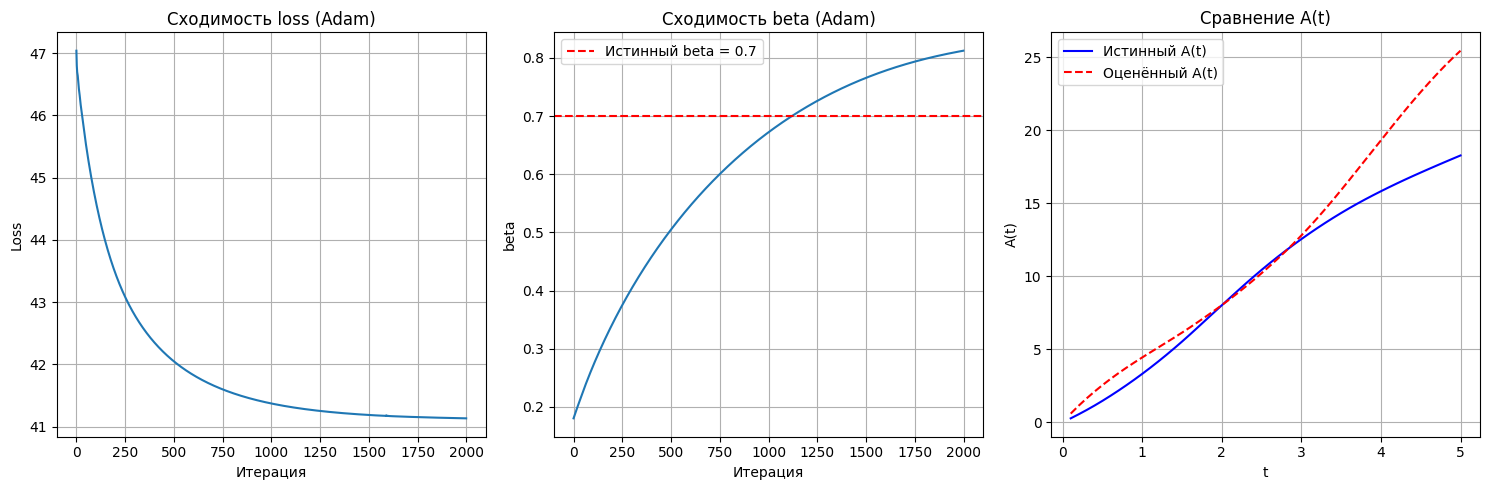

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import digamma, gammaln

# ==========================================
# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# ==========================================

np.random.seed(42)

N = 15
t_obs = np.random.uniform(0.5, 5.0, N)

# Температура
time_temp = np.linspace(0, 5, 10)
temp_values = 15 + 10 * np.sin(time_temp) + np.random.normal(0, 0.5, len(time_temp))
T_interp = interp1d(time_temp, temp_values, kind='linear', fill_value='extrapolate')

# Истинные параметры
w_true = np.array([0.3, 0.15, -0.02, 0.1, -0.05, 0.03, 0.1, -0.05])
beta_true = 0.7
age = 3.0
machine_type = 1.0

# ==========================================
# 2. ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ A(t) И ГРАДИЕНТОВ
# ==========================================

def build_features(s, T_func, age, machine_type):
    temp_s = T_func(s)
    x = np.column_stack([
        np.ones_like(s),
        s,
        s**2,
        np.sin(s),
        np.cos(s),
        temp_s,
        age * np.ones_like(s),
        machine_type * np.ones_like(s)
    ])
    return x

def compute_A_and_grad(t, w, T_func, age, machine_type, num_points=500):
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)
    alpha_vals = np.exp(X @ w)
    
    A_t = np.trapz(alpha_vals, s_grid)
    grad_vals = alpha_vals[:, None] * X
    grad_A = np.trapz(grad_vals, s_grid, axis=0)
    
    return A_t, grad_A

def compute_A_only(t, w, T_func, age, machine_type, num_points=500):
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)
    alpha_vals = np.exp(X @ w)
    return np.trapz(alpha_vals, s_grid)

# ==========================================
# 3. ГЕНЕРАЦИЯ ВЫБОРКИ
# ==========================================

def generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type):
    X_obs = []
    A_true = []
    for t in t_obs:
        A_t, _ = compute_A_and_grad(t, w_true, T_interp, age, machine_type)
        A_true.append(A_t)
        X_obs.append(np.random.gamma(A_t, 1/beta_true))
    return np.array(X_obs), np.array(A_true)

X_obs, A_true = generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type)

# ==========================================
# 4. ПОДХОД 2: ADAM (ВМЕСТО ГРАДИЕНТНОГО СПУСКА)
# ==========================================

def loss_and_grad_full(params, t_obs, X_obs, T_func, age, machine_type):
    w = params[:-1]
    beta = params[-1]
    
    if beta <= 0:
        return 1e10, np.zeros_like(params)
    
    N = len(t_obs)
    loss = 0.0
    grad_w = np.zeros_like(w)
    grad_beta = 0.0
    
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t, grad_A = compute_A_and_grad(t, w, T_func, age, machine_type)
        
        if A_t <= 0:
            return 1e10, np.zeros_like(params)
        
        loss -= A_t * np.log(beta) - gammaln(A_t) + (A_t - 1) * np.log(x) - beta * x
        
        dL_dA = -np.log(beta) - np.log(x) + digamma(A_t)
        grad_w += dL_dA * grad_A
        grad_beta += -A_t / beta + x
    
    if np.isnan(loss) or np.isinf(loss):
        return 1e10, np.zeros_like(params)
    
    grad = np.concatenate([grad_w, [grad_beta]])
    return loss, grad

def adam(params_init, loss_and_grad, args, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, max_iter=1000, tol=1e-6, verbose=True):
    """
    Adam optimizer.
    """
    params = params_init.copy()
    m = np.zeros_like(params)
    v = np.zeros_like(params)
    loss_history = []
    beta_history = []
    
    for t in range(1, max_iter + 1):
        loss, grad = loss_and_grad(params, *args)
        loss_history.append(loss)
        beta_history.append(params[-1])
        
        if np.isnan(loss) or np.isinf(loss):
            print(f"!!! Остановка на итерации {t}: loss = {loss}")
            break
        
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        
        params -= lr * m_hat / (np.sqrt(v_hat) + eps)
        
        # Принудительно beta > 0
        params[-1] = max(params[-1], 1e-6)
        
        if verbose and t % 50 == 0:
            print(f"Итерация {t}: loss = {loss:.6f}, beta = {params[-1]:.6f}")
        
        if np.linalg.norm(grad) < tol:
            if verbose:
                print(f"Сошлись на итерации {t} (норма градиента < {tol})")
            break
    
    return params, loss_history, beta_history

# ==========================================
# 5. ЗАПУСК ADAM
# ==========================================

print("\n" + "="*60)
print("ПОДХОД 2: ADAM (w + beta)")
print("="*60)

w_init = np.random.randn(8) * 0.01
beta_init = np.mean(X_obs) / np.var(X_obs)
params_init = np.concatenate([w_init, [beta_init]])

args = (t_obs, X_obs, T_interp, age, machine_type)

params_opt, loss_history, beta_history = adam(
    params_init, 
    loss_and_grad_full, 
    args,
    lr=1e-3,        # learning rate для Adam
    max_iter=2000,
    tol=1e-6,
    verbose=True
)

w_2 = params_opt[:-1]
beta_2 = params_opt[-1]

print("\n" + "-"*40)
print("РЕЗУЛЬТАТЫ ПОДХОДА 2 (ADAM):")
print("-"*40)
print(f"w = {w_2}")
print(f"beta = {beta_2:.6f}")
print(f"Количество итераций: {len(loss_history)}")
print(f"Финальный лосс: {loss_history[-1]:.6f}")

# ==========================================
# 6. СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ
# ==========================================

print("\n" + "="*60)
print("СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ")
print("="*60)

print(f"\nИстинный beta:  {beta_true:.6f}")
print(f"Оценка beta:    {beta_2:.6f}")
print(f"Отклонение:     {abs(beta_2 - beta_true):.6f}")

print(f"\nИстинный w:  {w_true}")
print(f"Оценка w:    {w_2}")

# ==========================================
# 7. ГРАФИКИ
# ==========================================

plt.figure(figsize=(15, 5))

# График сходимости loss
plt.subplot(1, 3, 1)
plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость loss (Adam)')
plt.grid(True)

# График beta
plt.subplot(1, 3, 2)
plt.plot(beta_history)
plt.axhline(y=beta_true, color='r', linestyle='--', label=f'Истинный beta = {beta_true}')
plt.xlabel('Итерация')
plt.ylabel('beta')
plt.title('Сходимость beta (Adam)')
plt.legend()
plt.grid(True)

# Сравнение A(t)
t_grid = np.linspace(0.1, 5.0, 50)
A_true_grid = []
A_est_grid = []

for t in t_grid:
    A_true_t, _ = compute_A_and_grad(t, w_true, T_interp, age, machine_type)
    A_est_t, _ = compute_A_and_grad(t, w_2, T_interp, age, machine_type)
    A_true_grid.append(A_true_t)
    A_est_grid.append(A_est_t)

plt.subplot(1, 3, 3)
plt.plot(t_grid, A_true_grid, 'b-', label='Истинный A(t)')
plt.plot(t_grid, A_est_grid, 'r--', label='Оценённый A(t)')
plt.xlabel('t')
plt.ylabel('A(t)')
plt.title('Сравнение A(t)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Новый подход считаем приближенное beta, выкидываем его на эатпе градиентного спуска как константу, и в конце считаем мтодом ММ при оптимальном A(t)

/tmp/ipykernel_1392/2153168650.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_t = np.trapz(alpha_vals, s_grid)
/tmp/ipykernel_1392/2153168650.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  grad_A = np.trapz(grad_vals, s_grid, axis=0)
/tmp/ipykernel_1392/2153168650.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(alpha_vals, s_grid)



ПОДХОД 3: MLE для w (без beta) + MM для beta (один раз в конце)
ГРАДИЕНТНЫЙ СПУСК С GRADIENT CLIPPING
Начальное w (умная инициализация): [1.05589652 0.         0.         0.         0.         0.
 0.         0.        ]
Итерация 50: loss = 2593.240044, grad_norm = 173248.773501
Итерация 100: loss = 2575.728882, grad_norm = 172385.314284
Итерация 150: loss = 2558.706492, grad_norm = 171574.686342
Итерация 200: loss = 2542.167702, grad_norm = 170777.480521
Итерация 250: loss = 2526.109347, grad_norm = 169993.832269
Итерация 300: loss = 2510.527260, grad_norm = 169223.856670
Итерация 350: loss = 2495.416331, grad_norm = 168467.640616
Итерация 400: loss = 2480.770568, grad_norm = 167725.243396
Итерация 450: loss = 2466.583168, grad_norm = 166996.697430
Итерация 500: loss = 2452.846579, grad_norm = 166282.009148
Итерация 550: loss = 2439.552574, grad_norm = 165581.159979
Итерация 600: loss = 2426.692320, grad_norm = 164894.107459
Итерация 650: loss = 2414.256447, grad_norm = 164220.786410


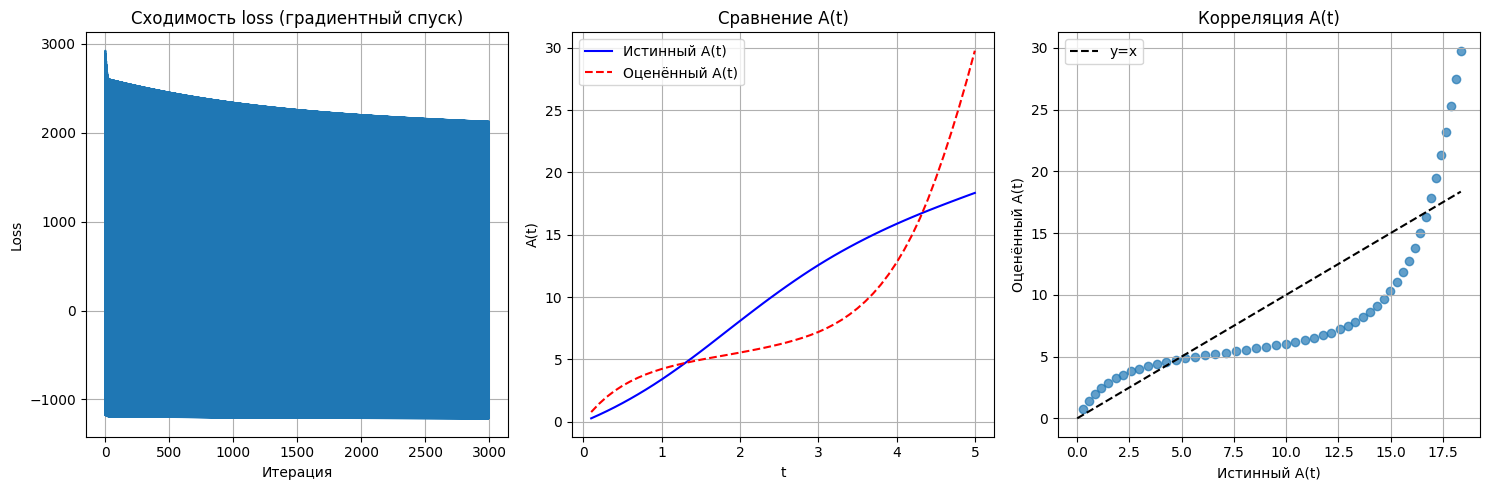


ПРЕДСКАЗАНИЯ И МЕТРИКИ

Метрики качества предсказания X(t):
MSE:  37.141628
RMSE: 6.094393
MAE:  4.463339
Средняя относительная ошибка: 0.405890
R^2 (коэффициент детерминации): 0.455231

Сравнение накопленных интенсивностей:
A(t) MSE:  14.938316
A(t) RMSE: 3.865012


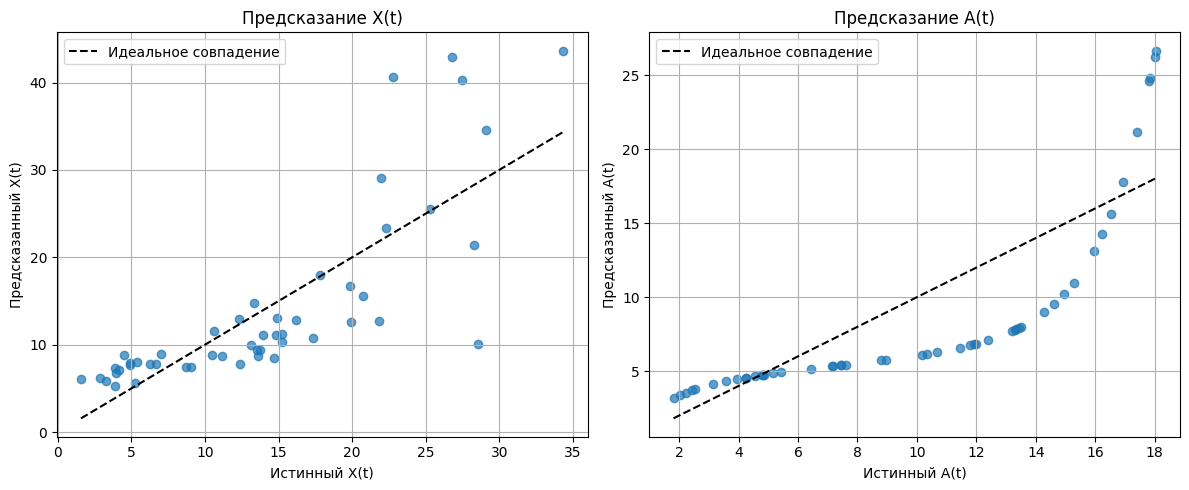


ПРЕДСКАЗАНИЯ ЗАВЕРШЕНЫ


In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import digamma, gammaln
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# 1. ГЕНЕРАЦИЯ СИНТЕТИЧЕСКИХ ДАННЫХ
# ==========================================

np.random.seed(42)

N = 50
t_obs = np.random.uniform(0.5, 5.0, N)

# Температура
time_temp = np.linspace(0, 5, 10)
temp_values = 15 + 10 * np.sin(time_temp) + np.random.normal(0, 0.5, len(time_temp))
T_interp = interp1d(time_temp, temp_values, kind='linear', fill_value='extrapolate')

# Истинные параметры
w_true = np.array([0.3, 0.15, -0.02, 0.1, -0.05, 0.03, 0.1, -0.05])
beta_true = 0.7
age = 3.0
machine_type = 1.0

# ==========================================
# 2. ФУНКЦИИ ДЛЯ ВЫЧИСЛЕНИЯ A(t) И ГРАДИЕНТОВ
# ==========================================

def build_features(s, T_func, age, machine_type):
    temp_s = T_func(s)
    x = np.column_stack([
        np.ones_like(s),
        s,
        s**2,
        np.sin(s),
        np.cos(s),
        temp_s,
        age * np.ones_like(s),
        machine_type * np.ones_like(s)
    ])
    return x

def compute_A_and_grad(t, w, T_func, age, machine_type, num_points=500):
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)
    alpha_vals = np.exp(X @ w)
    
    A_t = np.trapz(alpha_vals, s_grid)
    grad_vals = alpha_vals[:, None] * X
    grad_A = np.trapz(grad_vals, s_grid, axis=0)
    
    return A_t, grad_A

def compute_A_only(t, w, T_func, age, machine_type, num_points=500):
    s_grid = np.linspace(0, t, num_points)
    X = build_features(s_grid, T_func, age, machine_type)
    alpha_vals = np.exp(X @ w)
    return np.trapz(alpha_vals, s_grid)

# ==========================================
# 3. ГЕНЕРАЦИЯ ВЫБОРКИ
# ==========================================

def generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type):
    X_obs = []
    A_true = []
    for t in t_obs:
        A_t, _ = compute_A_and_grad(t, w_true, T_interp, age, machine_type)
        A_true.append(A_t)
        X_obs.append(np.random.gamma(A_t, 1/beta_true))
    return np.array(X_obs), np.array(A_true)

X_obs, A_true = generate_data(t_obs, w_true, beta_true, T_interp, age, machine_type)

# ==========================================
# 4. ПОДХОД 3: MLE ДЛЯ w, MM ДЛЯ beta (ОДИН РАЗ В КОНЦЕ)
# ==========================================

def loss_w_only(w, t_obs, X_obs, T_func, age, machine_type):
    """
    Лосс только по w — без beta!
    """
    loss = 0.0
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t = compute_A_only(t, w, T_func, age, machine_type)
        if A_t <= 0:
            return 1e10
        loss += 2 * (A_t * np.log(max(A_t / x, 1e-10)) - A_t)
    return loss

def grad_w_only(w, t_obs, X_obs, T_func, age, machine_type):
    """
    Градиент по w — без beta!
    """
    grad = np.zeros_like(w)
    for i in range(N):
        t = t_obs[i]
        x = X_obs[i]
        A_t, grad_A = compute_A_and_grad(t, w, T_func, age, machine_type)
        if A_t <= 0:
            return np.zeros_like(w)
        grad += 2 * np.log(max(A_t / x, 1e-10)) * grad_A
    return grad

def compute_beta_moments(w, t_obs, X_obs, T_func, age, machine_type):
    """Оценка beta через метод моментов (один раз в конце)."""
    A_sum = 0.0
    for t in t_obs:
        A_sum += compute_A_only(t, w, T_func, age, machine_type)
    return A_sum / np.sum(X_obs)

# ==========================================
# 5. ГРАДИЕНТНЫЙ СПУСК С GRADIENT CLIPPING
# ==========================================

def gradient_descent_w(w_init, loss_and_grad, args, lr=1e-5, max_iter=3000, tol=1e-6, clip_norm=1.0, verbose=True):
    """
    Градиентный спуск с gradient clipping.
    """
    w = w_init.copy()
    loss_history = []
    
    for i in range(max_iter):
        loss, grad = loss_and_grad(w, *args)
        loss_history.append(loss)
        
        if np.isnan(loss) or np.isinf(loss):
            print(f"!!! Остановка на итерации {i+1}: loss = {loss}")
            break
        
        # Gradient clipping
        grad_norm = np.linalg.norm(grad)
        if grad_norm > clip_norm:
            grad = grad / grad_norm * clip_norm
        
        # Обновление w
        w -= lr * grad
        
        if verbose and (i+1) % 50 == 0:
            print(f"Итерация {i+1}: loss = {loss:.6f}, grad_norm = {grad_norm:.6f}")
        
        if np.linalg.norm(grad) < tol:
            if verbose:
                print(f"Сошлись на итерации {i+1} (норма градиента < {tol})")
            break
    
    return w, loss_history

# ==========================================
# 6. ЗАПУСК ГРАДИЕНТНОГО СПУСКА
# ==========================================

print("\n" + "="*60)
print("ПОДХОД 3: MLE для w (без beta) + MM для beta (один раз в конце)")
print("ГРАДИЕНТНЫЙ СПУСК С GRADIENT CLIPPING")
print("="*60)

# Умная инициализация: используем метод моментов для гаммы
X_mean = np.mean(X_obs)
X_var = np.var(X_obs)
alpha_mom = X_mean**2 / X_var
beta_mom = X_mean / X_var

w_init = np.zeros(8)
w_init[0] = np.log(max(alpha_mom, 1e-6))

print(f"Начальное w (умная инициализация): {w_init}")

args = (t_obs, X_obs, T_interp, age, machine_type)

w_opt, loss_history = gradient_descent_w(
    w_init,
    lambda w, *args: (loss_w_only(w, *args), grad_w_only(w, *args)),
    args,
    lr=1e-1,
    max_iter=3000,
    tol=1e-6,
    clip_norm=1.0,
    verbose=True
)

print("\n" + "-"*40)
print("РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ w (ГРАДИЕНТНЫЙ СПУСК):")
print("-"*40)
print(f"Начальное w: {w_init}")
print(f"Оптимальное w: {w_opt}")
print(f"Финальный лосс: {loss_history[-1]:.6f}")

# ==========================================
# 7. ВЫЧИСЛЯЕМ beta ОДИН РАЗ В КОНЦЕ
# ==========================================

beta_est = compute_beta_moments(w_opt, t_obs, X_obs, T_interp, age, machine_type)

print("\n" + "="*60)
print("ОЦЕНКА beta (МЕТОДОМ МОМЕНТОВ):")
print("="*60)
print(f"beta = {beta_est:.6f}")

# ==========================================
# 8. СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ
# ==========================================

print("\n" + "="*60)
print("СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ")
print("="*60)

print(f"\nИстинный beta:  {beta_true:.6f}")
print(f"Оценка beta:    {beta_est:.6f}")
print(f"Отклонение:     {abs(beta_est - beta_true):.6f}")

print(f"\nИстинный w:  {w_true}")
print(f"Оценка w:    {w_opt}")

# ==========================================
# 9. ГРАФИКИ
# ==========================================

plt.figure(figsize=(15, 5))

# График сходимости loss
plt.subplot(1, 3, 1)
plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость loss (градиентный спуск)')
plt.grid(True)

# Сравнение A(t)
t_grid = np.linspace(0.1, 5.0, 50)
A_true_grid = []
A_est_grid = []

for t in t_grid:
    A_true_t, _ = compute_A_and_grad(t, w_true, T_interp, age, machine_type)
    A_est_t, _ = compute_A_and_grad(t, w_opt, T_interp, age, machine_type)
    A_true_grid.append(A_true_t)
    A_est_grid.append(A_est_t)

plt.subplot(1, 3, 2)
plt.plot(t_grid, A_true_grid, 'b-', label='Истинный A(t)')
plt.plot(t_grid, A_est_grid, 'r--', label='Оценённый A(t)')
plt.xlabel('t')
plt.ylabel('A(t)')
plt.title('Сравнение A(t)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(A_true_grid, A_est_grid, alpha=0.7)
plt.plot([0, max(A_true_grid)], [0, max(A_true_grid)], 'k--', label='y=x')
plt.xlabel('Истинный A(t)')
plt.ylabel('Оценённый A(t)')
plt.title('Корреляция A(t)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 10. ПРЕДСКАЗАНИЯ И МЕТРИКИ
# ==========================================

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЯ И МЕТРИКИ")
print("="*60)

# Предсказанные средние значения
X_pred = []
A_pred = []

for t in t_obs:
    A_t = compute_A_only(t, w_opt, T_interp, age, machine_type)
    A_pred.append(A_t)
    X_pred.append(A_t / beta_est)

X_pred = np.array(X_pred)
A_pred = np.array(A_pred)

# Метрики
mse = mean_squared_error(X_obs, X_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(X_obs, X_pred)

print(f"\nМетрики качества предсказания X(t):")
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

# Относительные метрики
relative_error = np.abs(X_obs - X_pred) / (np.abs(X_obs) + 1e-10)
mean_relative_error = np.mean(relative_error)

print(f"Средняя относительная ошибка: {mean_relative_error:.6f}")

# R^2
ss_res = np.sum((X_obs - X_pred) ** 2)
ss_tot = np.sum((X_obs - np.mean(X_obs)) ** 2)
r2 = 1 - (ss_res / (ss_tot + 1e-10))
print(f"R^2 (коэффициент детерминации): {r2:.6f}")

# Сравнение A(t)
print(f"\nСравнение накопленных интенсивностей:")
A_mse = mean_squared_error(A_true, A_pred)
A_rmse = np.sqrt(A_mse)
print(f"A(t) MSE:  {A_mse:.6f}")
print(f"A(t) RMSE: {A_rmse:.6f}")

# График предсказаний
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_obs, X_pred, alpha=0.7)
plt.plot([min(X_obs), max(X_obs)], [min(X_obs), max(X_obs)], 'k--', label='Идеальное совпадение')
plt.xlabel('Истинный X(t)')
plt.ylabel('Предсказанный X(t)')
plt.title('Предсказание X(t)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(A_true, A_pred, alpha=0.7)
plt.plot([min(A_true), max(A_true)], [min(A_true), max(A_true)], 'k--', label='Идеальное совпадение')
plt.xlabel('Истинный A(t)')
plt.ylabel('Предсказанный A(t)')
plt.title('Предсказание A(t)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ПРЕДСКАЗАНИЯ ЗАВЕРШЕНЫ")
print("="*60)